In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
url = 'https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart_disease.csv'
df = pd.read_csv(url)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
print(df.shape)
print(df.isnull().sum())

(303, 14)
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


target
1    165
0    138
Name: count, dtype: int64


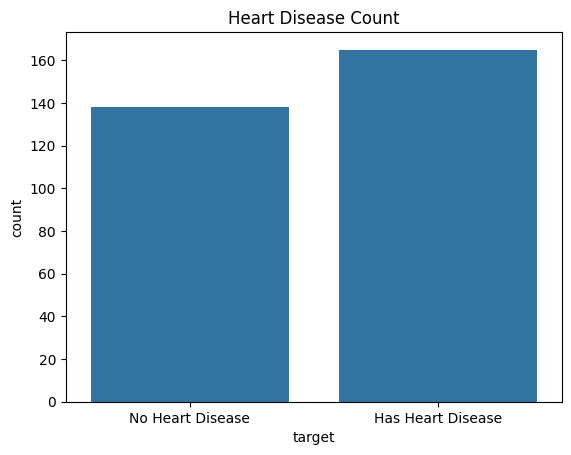

In [4]:
print(df['target'].value_counts())

sns.countplot(x='target', data=df)
plt.title('Heart Disease Count')
plt.xticks([0, 1], ['No Heart Disease', 'Has Heart Disease'])
plt.show()

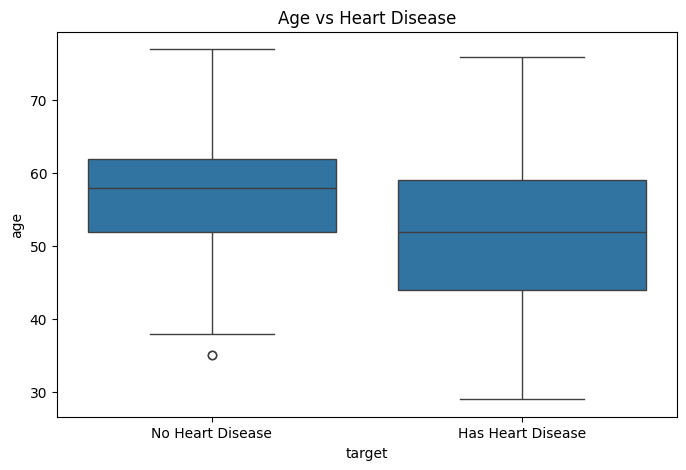

In [5]:
plt.figure(figsize=(8,5))
sns.boxplot(x='target', y='age', data=df)
plt.title('Age vs Heart Disease')
plt.xticks([0, 1], ['No Heart Disease', 'Has Heart Disease'])
plt.show()

In [6]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

print("Training patients:", X_train.shape[0])
print("Testing patients:", X_test.shape[0])
print("Model training complete! ✅")

Training patients: 242
Testing patients: 61
Model training complete! ✅


In [7]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy*100:.2f}%")

Model Accuracy: 75.41%


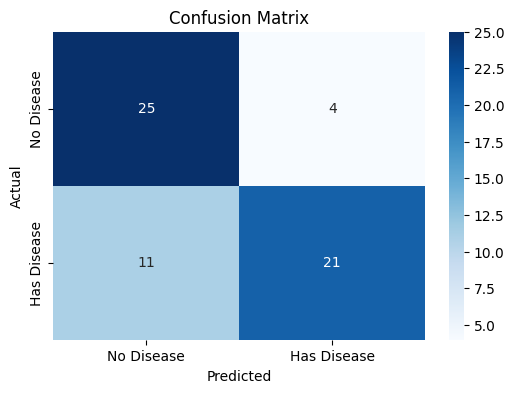

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0.5, 1.5], ['No Disease', 'Has Disease'])
plt.yticks([0.5, 1.5], ['No Disease', 'Has Disease'])
plt.show()

In [9]:
print(classification_report(y_test, y_pred,
      target_names=['No Disease', 'Has Disease']))

              precision    recall  f1-score   support

  No Disease       0.69      0.86      0.77        29
 Has Disease       0.84      0.66      0.74        32

    accuracy                           0.75        61
   macro avg       0.77      0.76      0.75        61
weighted avg       0.77      0.75      0.75        61



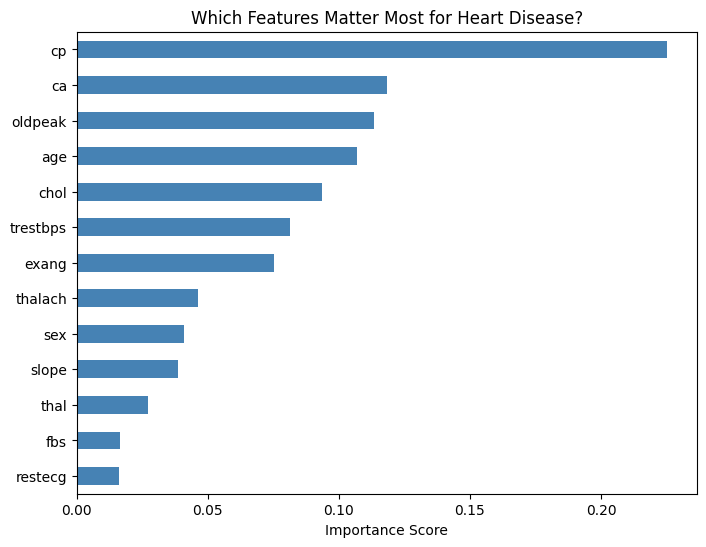

In [10]:
feature_importance = pd.Series(model.feature_importances_,
                    index=X.columns)
feature_importance.sort_values().plot(kind='barh',
                    color='steelblue', figsize=(8,6))
plt.title('Which Features Matter Most for Heart Disease?')
plt.xlabel('Importance Score')
plt.show()